# Imports

In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.config import get_cfg

# import our functions 
os.chdir("../../../util/preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

In [2]:
from detectron2.data.datasets import register_coco_instances
d = Dataset(data_path="../../data/raw_data/useable_data")
d.convert_binary_to_coco()
d.register_instances(rgb=True)

Init Dataset
Created 411 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/masks
Created 88 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/masks
Created 89 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/masks


Created 411 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/train/masks
Created 88 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/val/masks
Created 89 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/test/masks
Created 411 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/train/masks
Created 88 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/val/masks
Created 89 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/masks


In [3]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[10/11 05:55:10 d2.data.datasets.coco]: Loaded 411 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/images/train.json
[10/11 05:55:10 d2.data.datasets.coco]: Loaded 88 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/images/val.json
[10/11 05:55:10 d2.data.datasets.coco]: Loaded 89 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/test.json


In [4]:
iterations = 5000
model_name = "rgb-5000-1"

cfg = get_cfg()
cfg.MODELNAME = model_name
cfg.OUTPUT_DIR = f"../../../../models/rgb-testing/{cfg.MODELNAME}"
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train", "my_dataset_val")
cfg.DATASETS.TEST = ("my_dataset_test",)
cfg.DATALOADER.NUM_WORKERS = 1
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False # this is for our "no tumor" examples 
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.MAX_ITER = iterations   
cfg.SOLVER.STEPS = []        
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  

# # ROI Head Configuration (Accuracy-focused)
# cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512
# cfg.MODEL.ROI_HEADS.POSITIVE_FRACTION = 0.5  # More positive samples
# cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3   # Lower detection threshold
# cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.3     # Lower NMS for medical

cfg.SOLVER.BASE_LR = 0.0005   # Conservative LR for medical data
cfg.SOLVER.STEPS = [3000, 4000]  # Later LR reduction
cfg.SOLVER.GAMMA = 0.5        # Gentler LR decay
cfg.SOLVER.WARMUP_ITERS = 800
cfg.SOLVER.WARMUP_FACTOR = 0.1

In [5]:
model_path = "/projects/PUCHALLA/LLP2024/tumor-segmentation/models/rgb-testing/rgb-5000-1/model_final.pth"
cfg.MODEL.WEIGHTS = os.path.join(model_path)  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[10/11 05:55:32 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /projects/PUCHALLA/LLP2024/tumor-segmentation/models/rgb-testing/rgb-5000-1/model_final.pth ...


# Results

In [ ]:
# Function to display the original image with annotations and the predicted image
import copy

def display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, val_metadata):
    for d in random.sample(val_dataset_dicts, 1):
        im = cv2.imread(d["file_name"])
        outputs = predictor(im)

        # Create custom metadata with red colors
        red_metadata = copy.deepcopy(val_metadata)
        num_classes = len(red_metadata.thing_classes)
        red_metadata.thing_colors = [(0, 0, 255)] * num_classes 
        
        # Create a visualizer for ground truth (original colors)
        v_gt = Visualizer(im[:, :, ::-1],
                          metadata=red_metadata,
                          scale=0.5,
                          instance_mode=ColorMode.SEGMENTATION
        )
        out_gt = v_gt.draw_dataset_dict(d)
        

        
        # Create a visualizer for predictions with red metadata
        v_pred = Visualizer(im[:, :, ::-1],
                            metadata=red_metadata,
                            scale=0.5,
                            instance_mode=ColorMode.SEGMENTATION
        )
        
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))

        image_name = os.path.basename(d["file_name"])
        
        # Rest of your plotting code...
        fig, ax = plt.subplots(1, 2,)
        fig.suptitle("Comparing test image: test_30.jpg", fontsize=14, y=0.95)
        
        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Original Image with Annotations')
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Predicted Image')
        
        for a in ax:
            a.axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.92]) 
        plt.show()

# Example usage
display_original_and_prediction_with_annotations(test_dataset_dicts, predictor, test_metadata)


/home/am0532/.conda/envs/tumor-env/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


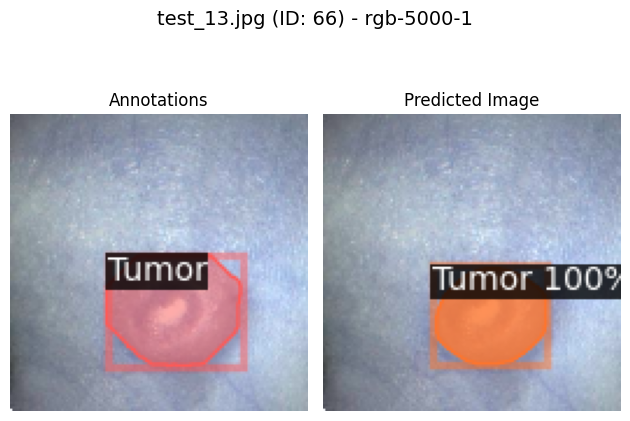

In [6]:
# Function to display the original image with annotations and the predicted image
import copy

def display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, val_metadata, image_id=None):
    
    d = None
    for item in val_dataset_dicts: 
        if item["image_id"] == image_id: 
            d = item
            break

    im = cv2.imread(d["file_name"])
    outputs = predictor(im)

    # Create custom metadata with red colors
    red_metadata = copy.deepcopy(val_metadata)
    num_classes = len(red_metadata.thing_classes)
    red_metadata.thing_colors = [(0, 0, 255)] * num_classes 
    
    # Create a visualizer for ground truth (original colors)
    v_gt = Visualizer(im[:, :, ::-1],
                        metadata=red_metadata,
                        scale=0.5,
                        instance_mode=ColorMode.SEGMENTATION
    )
    out_gt = v_gt.draw_dataset_dict(d)
    

    
    # Create a visualizer for predictions with red metadata
    v_pred = Visualizer(im[:, :, ::-1],
                        metadata=red_metadata,
                        scale=0.5,
                        instance_mode=ColorMode.SEGMENTATION
    )
    
    out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))

    image_name = os.path.basename(d["file_name"])
    model_name = os.path.basename(os.path.dirname(model_path))

    # Rest of your plotting code...
    fig, ax = plt.subplots(1, 2,)
    fig.suptitle(f"{image_name} (ID: {image_id}) - {model_name}", fontsize=14, y=0.95)
    
    ax[0].imshow(out_gt.get_image()[:, :, ::-1])
    ax[0].set_title('Annotations')
    ax[1].imshow(out_pred.get_image()[:, :, ::-1])
    ax[1].set_title('Predicted Image')
    
    for a in ax:
        a.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.92]) 
    # plt.show()

# Example usage
display_original_and_prediction_with_annotations(test_dataset_dicts, predictor, test_metadata, 66)


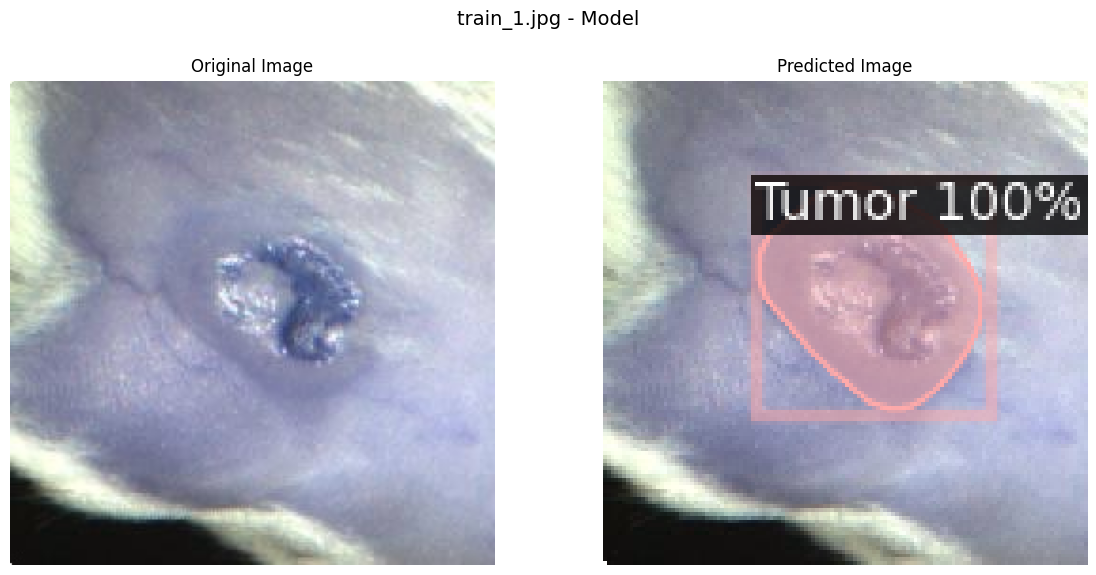

In [8]:
def display_image_prediction(image_path, predictor, metadata, model_path=None):
    """
    Display original image and prediction results for a single image.
    
    Args:
        image_path (str): Path to the input image
        predictor: Detectron2 predictor object
        metadata: Detectron2 metadata object containing class information
        model_path (str, optional): Path to model for display in title
    """
    
    # Read the image
    im = cv2.imread(image_path)
    if im is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Run prediction
    outputs = predictor(im)
    
    # Create visualizer for the original image (no annotations)
    v_original = Visualizer(im[:, :, ::-1],
                           metadata=metadata,
                           scale=0.5)
    
    # Create visualizer for predictions
    v_pred = Visualizer(im[:, :, ::-1],
                       metadata=metadata,
                       scale=0.5,
                       instance_mode=ColorMode.SEGMENTATION)
    
    out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))
    
    # Extract image name for title
    image_name = os.path.basename(image_path)
    model_name = os.path.basename(os.path.dirname(model_path)) if model_path else "Model"
    
    # Create the plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"{image_name} - {model_name}", fontsize=14, y=0.95)
    
    ax[0].imshow(im)
    ax[0].set_title('Original Image')
    ax[1].imshow(out_pred.get_image()[:, :, ::-1])
    ax[1].set_title('Predicted Image')
    
    for a in ax:
        a.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

image_path = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/images/train_1.jpg"
display_image_prediction(image_path=image_path, predictor=predictor, metadata=test_metadata)

